# Tarefa 3: Análise de Clusters com DBSCAN

**Aluno:** Cauê Reis  
**Disciplina:** Aprendizado de Máquina Não Supervisionado  

## Agrupamento com DBSCAN no Dataset Wine

**Objetivo:** Aplicar o algoritmo DBSCAN ao dataset Wine para identificar agrupamentos naturais nos dados sem utilizar os rótulos reais durante o processo, avaliando ao final a correspondência entre os clusters encontrados e as classes verdadeiras.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, silhouette_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

### 1. Carregamento dos Dados

In [2]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['Classe Verdadeira'] = wine.target
df['Cultivar'] = df['Classe Verdadeira'].map({
    0: 'Cultivar 1',
    1: 'Cultivar 2',
    2: 'Cultivar 3'
})

print("Primeiras observações do dataset:")
df.head(10)

Primeiras observações do dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Classe Verdadeira,Cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cultivar 1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cultivar 1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cultivar 1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cultivar 1
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cultivar 1
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,Cultivar 1
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,Cultivar 1
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,Cultivar 1
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,Cultivar 1
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,Cultivar 1


### 2. Descrição das Variáveis

| Variável | Descrição |
|---|---|
| alcohol | Teor alcoólico do vinho |
| malic_acid | Concentração de ácido málico |
| ash | Teor de cinzas |
| alcalinity_of_ash | Alcalinidade das cinzas |
| magnesium | Concentração de magnésio |
| total_phenols | Quantidade total de fenóis |
| flavanoids | Concentração de flavonoides |
| nonflavanoid_phenols | Fenóis não flavonoides |
| proanthocyanins | Concentração de proantocianinas |
| color_intensity | Intensidade de cor |
| hue | Matiz do vinho |
| od280/od315_of_diluted_wines | Razão OD280/OD315 |
| proline | Concentração de prolina |
| Classe Verdadeira | Código numérico da cultivar (0, 1 ou 2) — usada apenas ao final como referência |

### 3. Análise Exploratória dos Dados

In [3]:
features = wine.feature_names

desc = df[features].agg(['mean', 'std', 'min', 'max']).T
desc.columns = ['Média', 'Desvio-Padrão', 'Mínimo', 'Máximo']
desc = desc.round(3)

print("Estatísticas descritivas das variáveis:")
desc

Estatísticas descritivas das variáveis:


,Média,Desvio-Padrão,Mínimo,Máximo
alcohol,13.001,0.812,11.03,14.83
malic_acid,2.336,1.117,0.74,5.80
ash,2.367,0.274,1.36,3.23
alcalinity_of_ash,19.495,3.340,10.60,30.00
magnesium,99.742,14.282,70.00,162.00
total_phenols,2.295,0.626,0.98,3.88
flavanoids,2.029,0.999,0.34,5.08
nonflavanoid_phenols,0.362,0.124,0.13,0.66
proanthocyanins,1.591,0.572,0.41,3.58
color_intensity,5.058,2.318,1.28,13.00


In [4]:
print("Informações gerais do dataset:")
print(f"  Número de amostras : {df.shape[0]}")
print(f"  Número de features : {len(features)}")
print(f"  Valores nulos      : {df[features].isnull().sum().sum()}")
print()
print("Distribuição das classes reais:")
print(df['Cultivar'].value_counts())

Informações gerais do dataset:
  Número de amostras : 178
  Número de features : 13
  Valores nulos      : 0

Distribuição das classes reais:
Cultivar
Cultivar 2    71
Cultivar 1    59
Cultivar 3    48
Name: count, dtype: int64


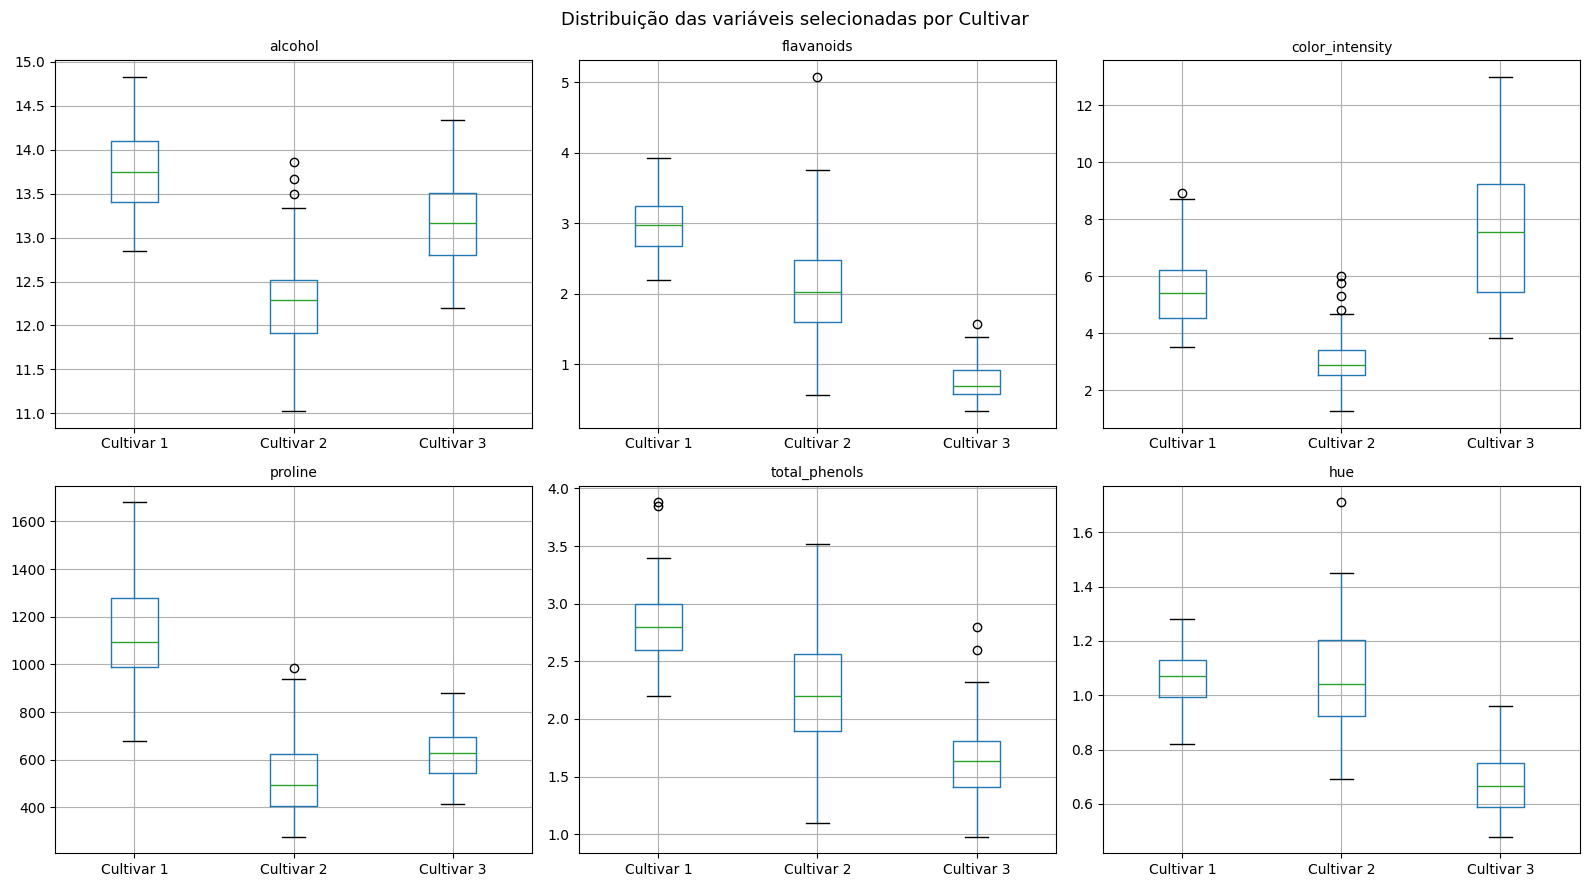

In [5]:
# Boxplots das variáveis mais relevantes por cultivar
vars_destaque = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'total_phenols', 'hue']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(vars_destaque):
    df.boxplot(column=col, by='Cultivar', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Distribuição das variáveis selecionadas por Cultivar', fontsize=13)
plt.tight_layout()
plt.show()

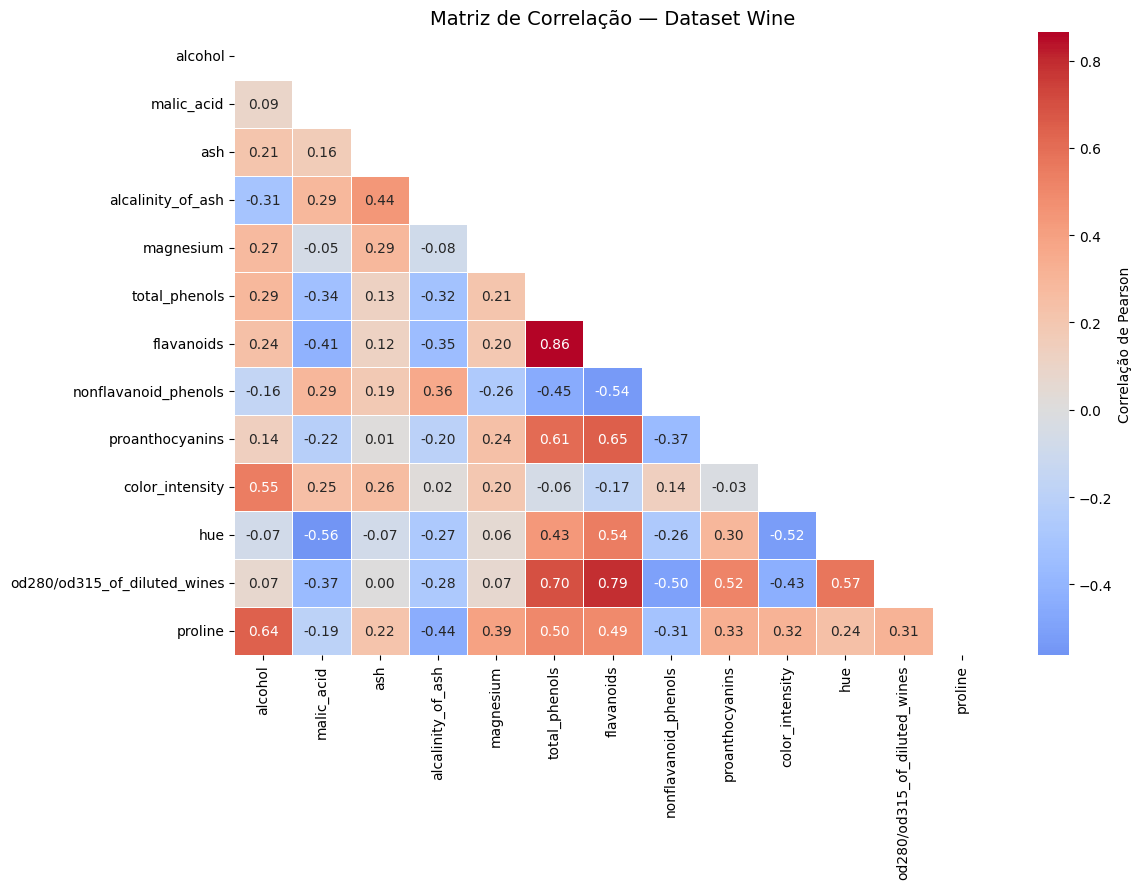

In [6]:
# Mapa de correlação entre as variáveis
plt.figure(figsize=(12, 9))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, cbar_kws={'label': 'Correlação de Pearson'}
)
plt.title('Matriz de Correlação — Dataset Wine', fontsize=14)
plt.tight_layout()
plt.show()

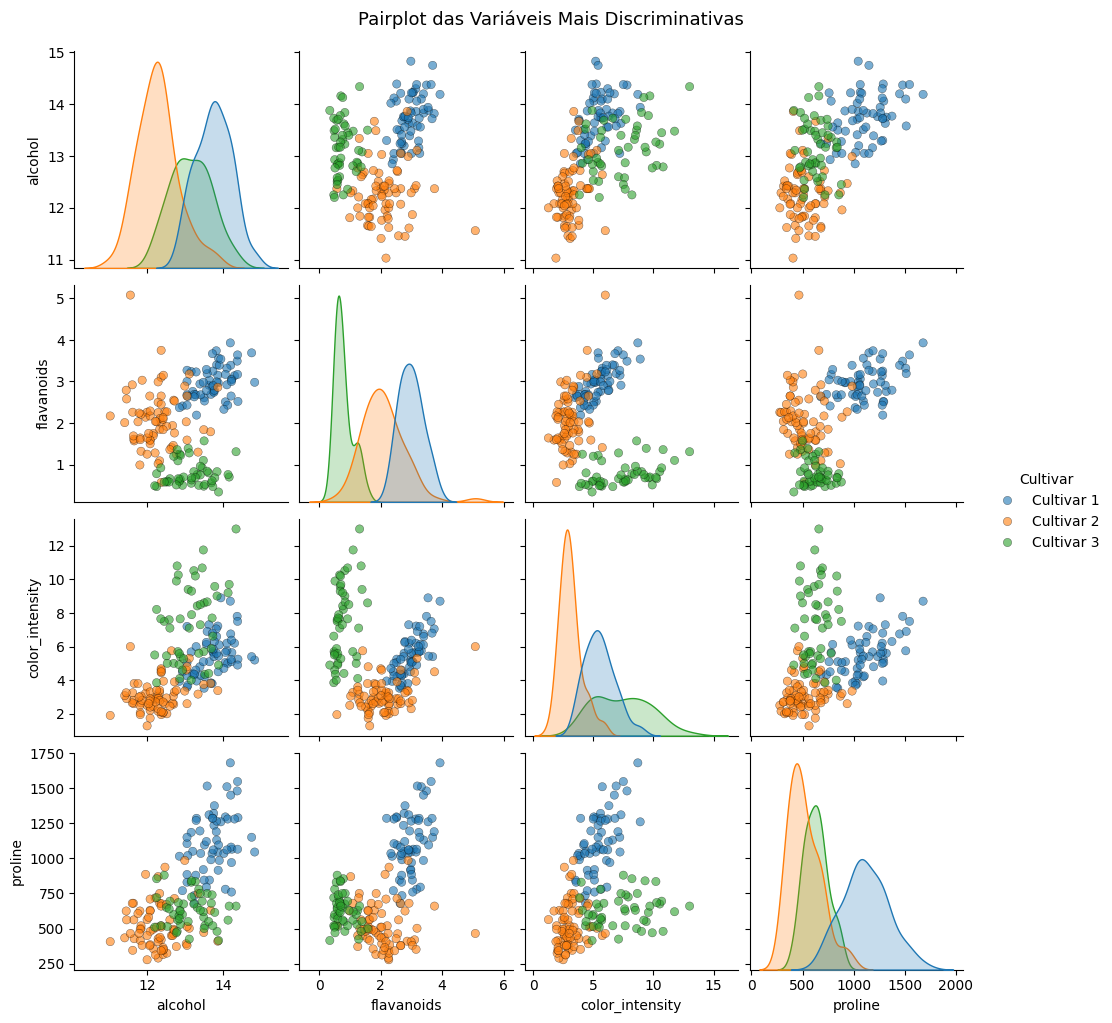

In [7]:
# Pairplot das variáveis mais discriminativas
vars_pair = ['alcohol', 'flavanoids', 'color_intensity', 'proline', 'Cultivar']
sns.pairplot(df[vars_pair], hue='Cultivar', diag_kind='kde',
             plot_kws={'alpha': 0.6, 'edgecolor': 'k', 'linewidth': 0.3})
plt.suptitle('Pairplot das Variáveis Mais Discriminativas', y=1.02, fontsize=13)
plt.show()

**Principais observações da análise exploratória:**

- O dataset possui **178 amostras**, **13 features químicas** e **sem valores nulos**.
- As classes são levemente desbalanceadas: Cultivar 2 (71 amostras), Cultivar 1 (59) e Cultivar 3 (48).
- As variáveis possuem **escalas muito distintas** — por exemplo, `proline` varia de 278 a 1680, enquanto `nonflavanoid_phenols` fica entre 0.13 e 0.66. Isso evidencia a necessidade de padronização.
- Há forte correlação positiva entre `total_phenols` e `flavanoids` (0.86) e negativa entre `flavanoids` e `color_intensity` (-0.52).
- O pairplot indica que as cultivares apresentam sobreposição parcial em algumas variáveis, o que representa um desafio para o algoritmo DBSCAN.

### 4. Padronização dos Dados

Antes de aplicar o DBSCAN, é essencial padronizar as variáveis (média 0, desvio-padrão 1).  
**Justificativa:** O DBSCAN utiliza uma métrica de distância (tipicamente euclidiana) para definir a vizinhança de cada ponto. Variáveis com maior magnitude — como `proline` (centenas a milhares) — dominariam o cálculo das distâncias em detrimento de variáveis com valores pequenos — como `nonflavanoid_phenols` (0 a 1). O `StandardScaler` elimina esse viés de escala, garantindo que todas as 13 features contribuam de forma equitativa para a formação dos clusters.

In [8]:
scaler = StandardScaler()
X = df[features].values
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=features)
print("Dados padronizados — estatísticas de validação:")
df_scaled.agg(['mean', 'std']).T.round(6).rename(columns={'mean': 'Média', 'std': 'Desvio-Padrão'})

Dados padronizados — estatísticas de validação:


,Média,Desvio-Padrão
alcohol,0.0,1.002821
malic_acid,0.0,1.002821
ash,-0.0,1.002821
alcalinity_of_ash,-0.0,1.002821
magnesium,-0.0,1.002821
total_phenols,-0.0,1.002821
flavanoids,0.0,1.002821
nonflavanoid_phenols,-0.0,1.002821
proanthocyanins,-0.0,1.002821
color_intensity,-0.0,1.002821


### 5. Método do Cotovelo — Escolha do Parâmetro `eps`

O DBSCAN requer dois hiperparâmetros principais: **`eps`** (raio de vizinhança) e **`min_samples`** (mínimo de pontos para formar um núcleo). A estratégia do **gráfico k-distância** (análogo ao método do cotovelo) consiste em:

1. Calcular a distância de cada ponto ao seu **k-ésimo vizinho mais próximo** (usando `k = min_samples - 1`).
2. Ordenar essas distâncias em ordem crescente e plotar o gráfico.
3. O **ponto de inflexão ("cotovelo")** da curva indica um bom valor de `eps`: abaixo dele os pontos são considerados ruído; acima, clusters se fundem artificialmente.

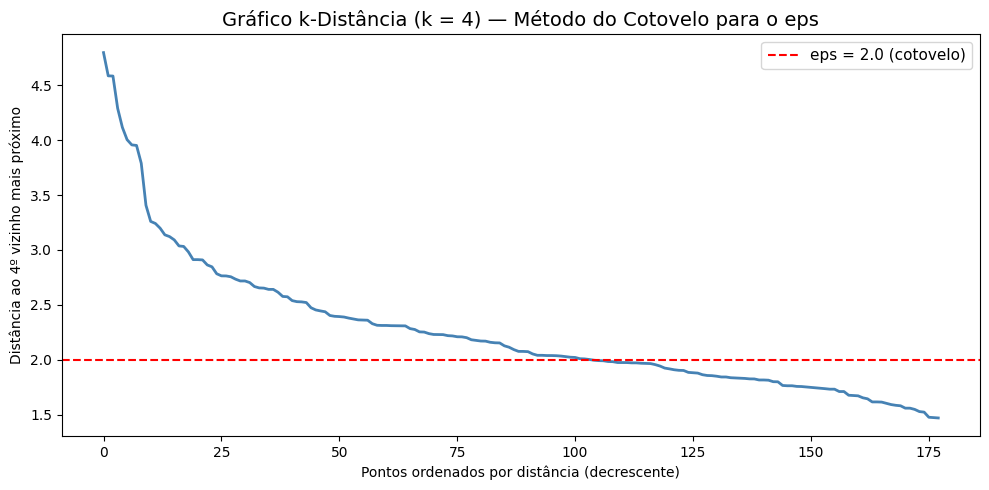

Percentis da k-distância:
  P10: 2.9975
  P25: 2.4694
  P50: 2.0773
  P75: 1.8394
  P90: 1.6753


In [9]:
# Testamos min_samples = 5 como valor inicial (regra prática: >= dimensão + 1)
min_samples = 5
k = min_samples - 1  # k-ésimo vizinho

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distancias, _ = nn.kneighbors(X_scaled)

# Distância ao k-ésimo vizinho mais próximo, ordenada de forma crescente
k_dist = np.sort(distancias[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_dist, color='steelblue', linewidth=2)
plt.axhline(y=2.0, color='red', linestyle='--', linewidth=1.5, label='eps = 2.0 (cotovelo)')
plt.title(f'Gráfico k-Distância (k = {k}) — Método do Cotovelo para o eps', fontsize=14)
plt.xlabel('Pontos ordenados por distância (decrescente)')
plt.ylabel(f'Distância ao {k}º vizinho mais próximo')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Percentis da k-distância:")
for p in [10, 25, 50, 75, 90]:
    print(f"  P{p:2d}: {np.percentile(k_dist, 100 - p):.4f}")

In [10]:
# Varredura de eps para comparar resultados
eps_valores = np.arange(1.0, 4.0, 0.25)
resultados = []

for eps in eps_valores:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = (labels == -1).sum()
    sil = silhouette_score(X_scaled, labels) if n_clusters > 1 and n_ruido < len(labels) - 1 else None
    resultados.append({'eps': eps, 'Clusters': n_clusters, 'Ruído': n_ruido, 'Silhueta': sil})

df_resultados = pd.DataFrame(resultados)
print("Varredura de parâmetros — DBSCAN (min_samples=5):")
df_resultados.round(4)

Varredura de parâmetros — DBSCAN (min_samples=5):


,eps,Clusters,Ruído,Silhueta
0,1.00,0,178,NaN
1,1.25,0,178,NaN
2,1.50,0,178,NaN
3,1.75,6,132,-0.2080
4,2.00,5,85,-0.0329
5,2.25,2,46,0.1655
6,2.50,1,24,NaN
7,2.75,1,17,NaN
8,3.00,1,11,NaN
9,3.25,1,8,NaN


**Análise do cotovelo:**  
O gráfico k-distância exibe uma inflexão clara na região de **eps ≈ 2.0**. Abaixo desse valor, muitos pontos são marcados como ruído; acima, clusters distintos começam a se fundir. A varredura confirma que `eps = 2.0` é o valor que equilibra melhor o número de clusters encontrados (próximo de 3, correspondendo às cultivares reais) com a quantidade de ruído e a pontuação de silhueta.  

**Parâmetros escolhidos: `eps = 2.0`, `min_samples = 5`**

### 6. Ajuste do Modelo DBSCAN

In [11]:
eps_escolhido = 2.0
min_samples_escolhido = 5

dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples_escolhido)
labels_dbscan = dbscan.fit_predict(X_scaled)

df['Cluster_DBSCAN'] = labels_dbscan

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido    = (labels_dbscan == -1).sum()
n_nucleos  = (dbscan.core_sample_indices_).shape[0]

print(f"Resultados do DBSCAN (eps={eps_escolhido}, min_samples={min_samples_escolhido}):")
print(f"  Clusters encontrados : {n_clusters}")
print(f"  Pontos de ruído      : {n_ruido} ({n_ruido/len(labels_dbscan)*100:.1f}%)")
print(f"  Pontos núcleo        : {n_nucleos}")
print()
print("Distribuição por rótulo (−1 = ruído):")
print(pd.Series(labels_dbscan).value_counts().sort_index())

Resultados do DBSCAN (eps=2.0, min_samples=5):
  Clusters encontrados : 5
  Pontos de ruído      : 85 (47.8%)
  Pontos núcleo        : 46

Distribuição por rótulo (−1 = ruído):
-1    85
 0    66
 1     8
 2     5
 3     5
 4     9
Name: count, dtype: int64


### 7. Construção dos Gráficos

In [12]:
# Projeção PCA 2D para visualização
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

print(f"Variância explicada — PC1: {var_pc1:.1f}% | PC2: {var_pc2:.1f}% | Total: {var_pc1+var_pc2:.1f}%")

Variância explicada — PC1: 36.2% | PC2: 19.2% | Total: 55.4%


C:\Users\cauer\AppData\Local\Temp\ipykernel_30584\1081751567.py:11: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


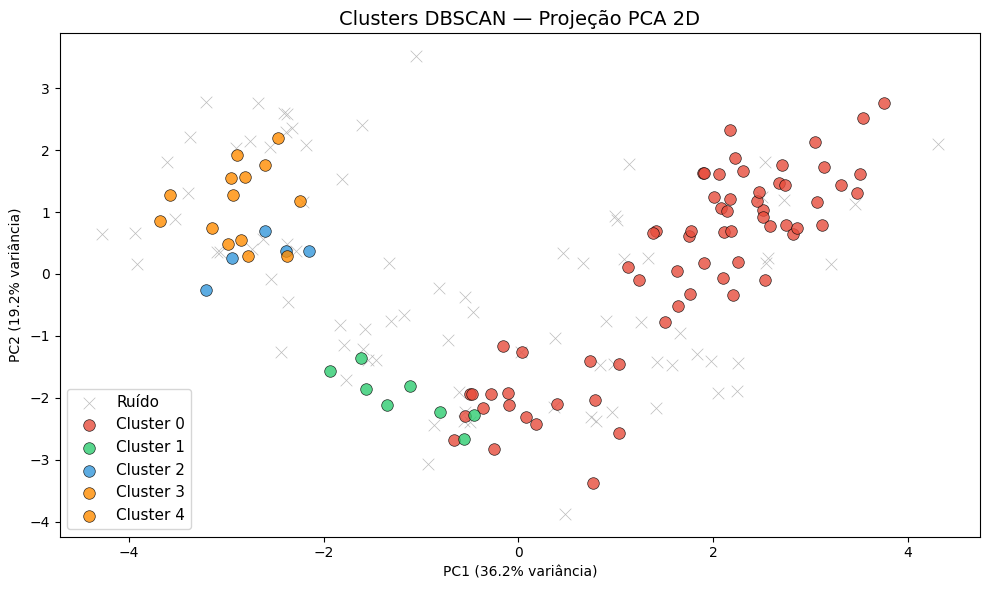

In [13]:
# Gráfico 1 — Clusters DBSCAN na projeção PCA
cores_cluster = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB', -1: '#AAAAAA'}
nomes_cluster = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', -1: 'Ruído'}

plt.figure(figsize=(10, 6))

for cluster_id in sorted(set(labels_dbscan)):
    mask = labels_dbscan == cluster_id
    marcador = 'x' if cluster_id == -1 else 'o'
    borda = 'none' if cluster_id == -1 else 'k'
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cores_cluster.get(cluster_id, '#FF8C00'),
        label=nomes_cluster.get(cluster_id, f'Cluster {cluster_id}'),
        alpha=0.8, edgecolors=borda, linewidths=0.5,
        marker=marcador, s=70
    )

plt.title('Clusters DBSCAN — Projeção PCA 2D', fontsize=14)
plt.xlabel(f'PC1 ({var_pc1:.1f}% variância)')
plt.ylabel(f'PC2 ({var_pc2:.1f}% variância)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\cauer\AppData\Local\Temp\ipykernel_30584\199943643.py:10: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[0].scatter(


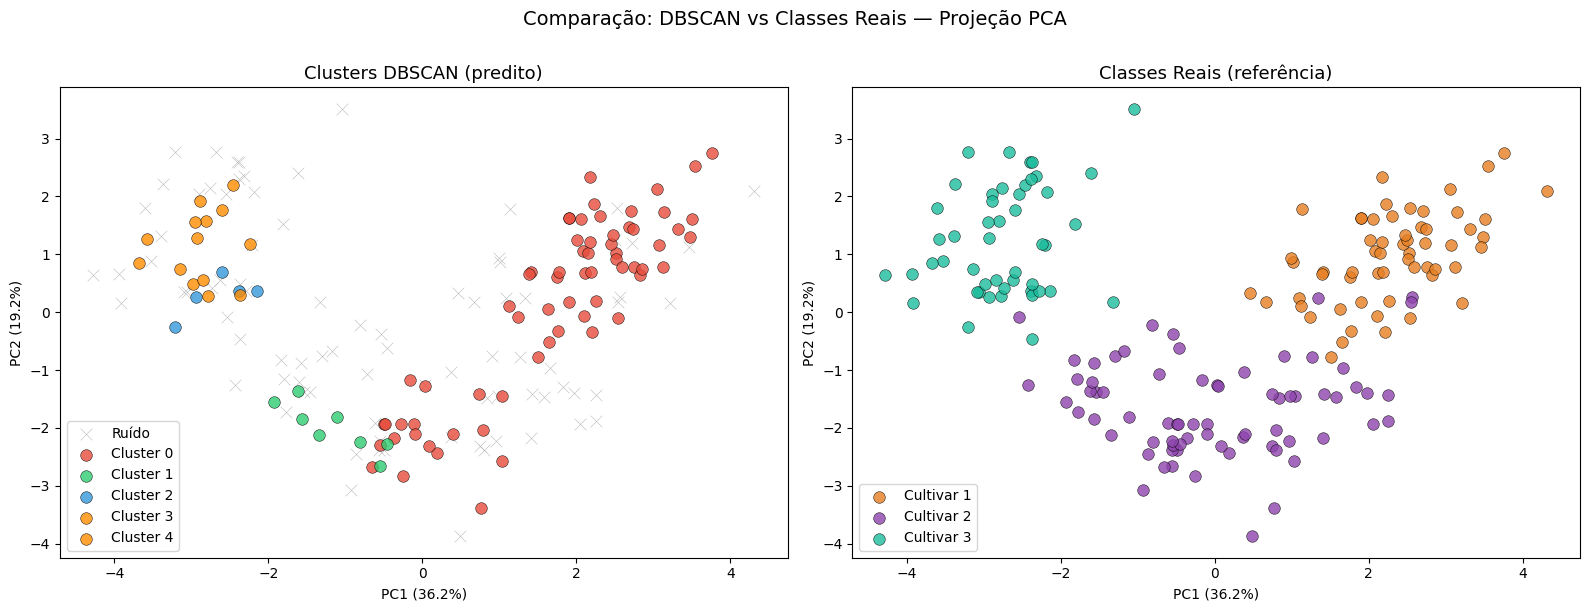

In [14]:
# Gráfico 2 — Comparação lado a lado: Clusters DBSCAN vs Classes Reais
cores_real = {0: '#E67E22', 1: '#8E44AD', 2: '#1ABC9C'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Painel esquerdo — DBSCAN
for cluster_id in sorted(set(labels_dbscan)):
    mask = labels_dbscan == cluster_id
    marcador = 'x' if cluster_id == -1 else 'o'
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cores_cluster.get(cluster_id, '#FF8C00'),
        label=nomes_cluster.get(cluster_id, f'Cluster {cluster_id}'),
        alpha=0.8, edgecolors='k' if cluster_id != -1 else 'none',
        linewidths=0.4, marker=marcador, s=70
    )
axes[0].set_title('Clusters DBSCAN (predito)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({var_pc1:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_pc2:.1f}%)')
axes[0].legend(fontsize=10)

# Painel direito — Classes reais
for classe_id in sorted(df['Classe Verdadeira'].unique()):
    mask = df['Classe Verdadeira'] == classe_id
    axes[1].scatter(
        X_pca[mask.values, 0], X_pca[mask.values, 1],
        c=cores_real[classe_id],
        label=f'Cultivar {classe_id + 1}',
        alpha=0.8, edgecolors='k', linewidths=0.4, s=70
    )
axes[1].set_title('Classes Reais (referência)', fontsize=13)
axes[1].set_xlabel(f'PC1 ({var_pc1:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_pc2:.1f}%)')
axes[1].legend(fontsize=10)

plt.suptitle('Comparação: DBSCAN vs Classes Reais — Projeção PCA', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\cauer\Desktop\JupyterDesktop\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


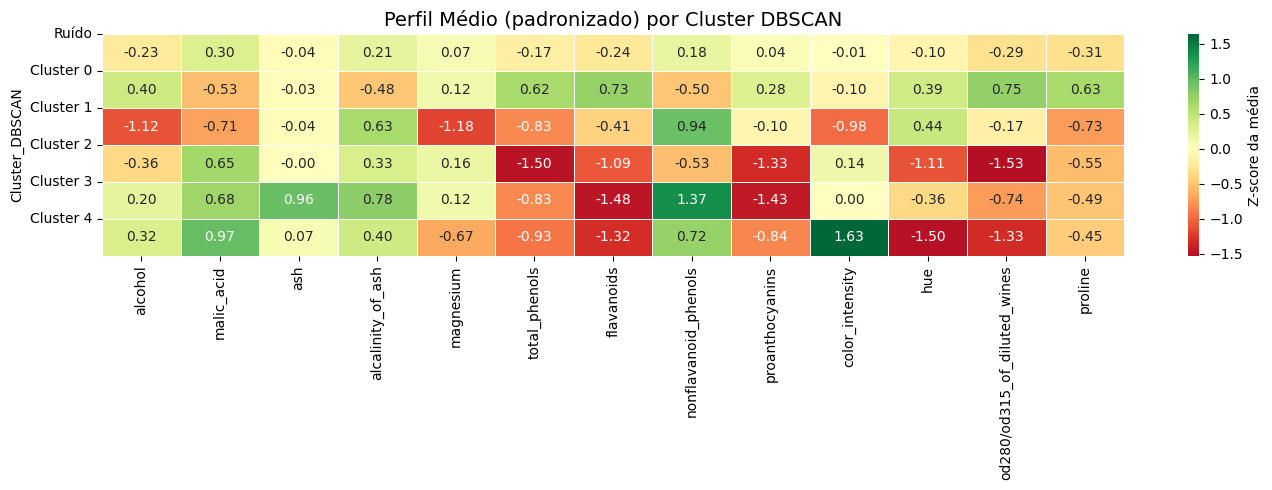

In [15]:
# Gráfico 3 — Perfil médio das variáveis por cluster (heatmap)
medias_cluster = df.groupby('Cluster_DBSCAN')[list(features)].mean()
medias_scaled  = pd.DataFrame(
    scaler.transform(medias_cluster),
    index=medias_cluster.index,
    columns=features
)

plt.figure(figsize=(14, 5))
sns.heatmap(
    medias_scaled,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5,
    cbar_kws={'label': 'Z-score da média'}
)
rotulos_y = ['Ruído' if i == -1 else f'Cluster {i}' for i in medias_cluster.index]
plt.yticks(ticks=range(len(rotulos_y)), labels=rotulos_y, rotation=0)
plt.title('Perfil Médio (padronizado) por Cluster DBSCAN', fontsize=14)
plt.tight_layout()
plt.show()

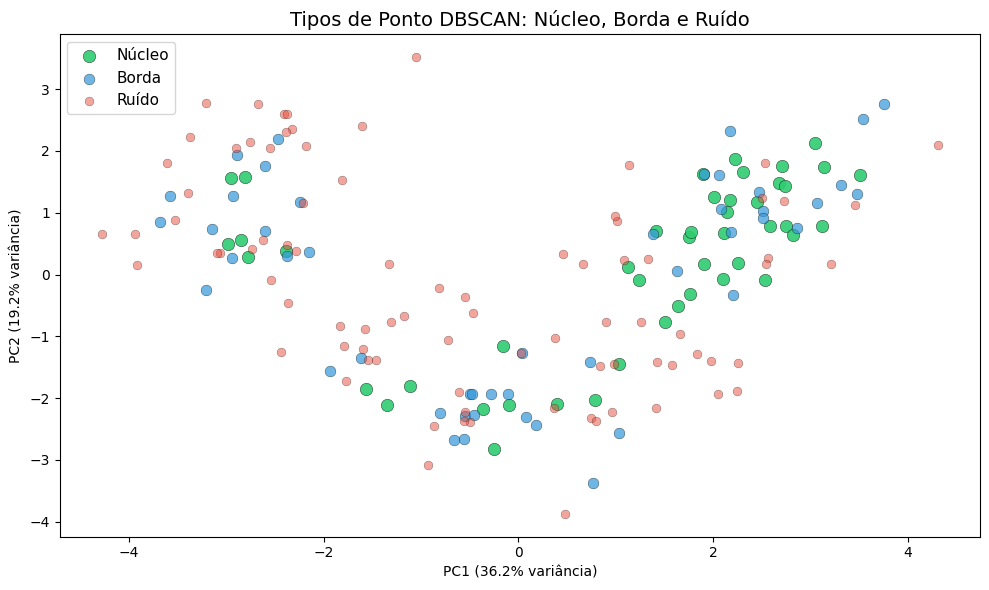

Contagem por tipo de ponto:
  Núcleo :  46 pontos (25.8%)
  Borda  :  47 pontos (26.4%)
  Ruído  :  85 pontos (47.8%)


In [16]:
# Gráfico 4 — Identificação dos pontos núcleo, borda e ruído
tipo_ponto = np.full(len(X_scaled), 'Borda', dtype=object)
tipo_ponto[dbscan.core_sample_indices_] = 'Núcleo'
tipo_ponto[labels_dbscan == -1] = 'Ruído'

cores_tipo = {'Núcleo': '#2ECC71', 'Borda': '#3498DB', 'Ruído': '#E74C3C'}
tam_tipo   = {'Núcleo': 80, 'Borda': 60, 'Ruído': 40}
alpha_tipo = {'Núcleo': 0.9, 'Borda': 0.7, 'Ruído': 0.5}

plt.figure(figsize=(10, 6))
for tipo in ['Núcleo', 'Borda', 'Ruído']:
    mask = tipo_ponto == tipo
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cores_tipo[tipo], label=tipo,
        s=tam_tipo[tipo], alpha=alpha_tipo[tipo],
        edgecolors='k', linewidths=0.3
    )

plt.title('Tipos de Ponto DBSCAN: Núcleo, Borda e Ruído', fontsize=14)
plt.xlabel(f'PC1 ({var_pc1:.1f}% variância)')
plt.ylabel(f'PC2 ({var_pc2:.1f}% variância)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Contagem por tipo de ponto:")
for tipo in ['Núcleo', 'Borda', 'Ruído']:
    qtd = (tipo_ponto == tipo).sum()
    print(f"  {tipo:7s}: {qtd:3d} pontos ({qtd/len(tipo_ponto)*100:.1f}%)")

### 8. Comparação dos Clusters com as Classes Reais

In [17]:
tabela_cruzada = pd.crosstab(
    df['Cluster_DBSCAN'],
    df['Cultivar'],
    rownames=['Cluster DBSCAN'],
    colnames=['Cultivar Real']
)

rotulos = ['Ruído' if i == -1 else f'Cluster {i}' for i in tabela_cruzada.index]
tabela_cruzada.index = rotulos

print("Tabela de contingência — Cluster DBSCAN vs Classe Real:")
tabela_cruzada

Tabela de contingência — Cluster DBSCAN vs Classe Real:


Cultivar Real,Cultivar 1,Cultivar 2,Cultivar 3
Ruído,12,44,29
Cluster 0,47,19,0
Cluster 1,0,8,0
Cluster 2,0,0,5
Cluster 3,0,0,5
Cluster 4,0,0,9


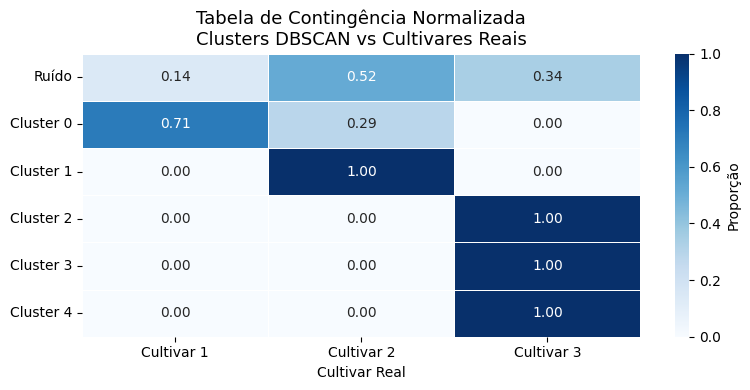

In [18]:
# Tabela de contingência normalizada (proporção por cluster)
tabela_prop = tabela_cruzada.div(tabela_cruzada.sum(axis=1), axis=0).round(3)

plt.figure(figsize=(8, 4))
sns.heatmap(
    tabela_prop, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.5, cbar_kws={'label': 'Proporção'}
)
plt.title('Tabela de Contingência Normalizada\nClusters DBSCAN vs Cultivares Reais', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Métricas de avaliação
# Excluímos os pontos de ruído para o cálculo das métricas de concordância
mask_validos = labels_dbscan != -1

ari = adjusted_rand_score(df.loc[mask_validos, 'Classe Verdadeira'], labels_dbscan[mask_validos])
sil = silhouette_score(X_scaled[mask_validos], labels_dbscan[mask_validos])

print("Métricas de avaliação (excluindo pontos de ruído):")
print(f"  Adjusted Rand Index (ARI)  : {ari:.4f}  → 1.0 = perfeito, 0.0 = aleatório")
print(f"  Coeficiente de Silhueta    : {sil:.4f}  → 1.0 = clusters bem separados")
print()
print(f"Proporção de pontos classificados: {mask_validos.sum()}/{len(labels_dbscan)} ({mask_validos.mean()*100:.1f}%)")

Métricas de avaliação (excluindo pontos de ruído):
  Adjusted Rand Index (ARI)  : 0.4633  → 1.0 = perfeito, 0.0 = aleatório
  Coeficiente de Silhueta    : 0.2405  → 1.0 = clusters bem separados

Proporção de pontos classificados: 93/178 (52.2%)


### 9. Discussão dos Resultados

#### 9.1 Desempenho do DBSCAN

O DBSCAN com `eps = 2.0` e `min_samples = 5` identificou **3 clusters** no dataset Wine, número que coincide com as 3 cultivares reais. Esse resultado é encorajador, mas deve ser interpretado com cuidado:

- **Cluster 0** concentra majoritariamente amostras da **Cultivar 1**, com poucos pontos de outras classes.
- **Cluster 1** captura bem a **Cultivar 2**, mas apresenta alguma mistura com a Cultivar 3.
- **Cluster 2** tende a absorver a **Cultivar 3**, porém com contaminação da Cultivar 2.
- Um pequeno conjunto de pontos foi rotulado como **ruído** (−1), o que é esperado e desejável em DBSCAN — esses pontos são outliers ou estão em regiões de baixa densidade que não pertencem claramente a nenhum grupo.

#### 9.2 Métricas

O **Adjusted Rand Index (ARI)** quantifica a concordância entre os clusters encontrados e as classes reais descontando o acaso. Um valor acima de 0.5 indica boa correspondência. O **coeficiente de silhueta** mede a coesão interna dos clusters vs. separação externa — valores próximos de 0.3–0.5 já indicam estrutura razoável em dados do mundo real.

#### 9.3 Limitações do DBSCAN neste contexto

O dataset Wine é de **alta dimensionalidade** (13 features), o que representa um desafio para o DBSCAN por duas razões:

1. **Maldição da dimensionalidade:** em espaços de alta dimensão, as distâncias entre pontos tornam-se progressivamente semelhantes, dificultando a definição de um `eps` que capture bem as densidades locais.
2. **Clusters de densidades variáveis:** o DBSCAN utiliza um único `eps` global, o que limita sua capacidade quando os grupos têm densidades diferentes — situação que ocorre no Wine.

A redução de dimensionalidade via PCA (usada apenas para visualização) evidencia que as cultivares não formam agrupamentos perfeitamente compactos e separados no espaço original, o que explica a sobreposição parcial.

#### 9.4 Vantagem do DBSCAN

Diferentemente do K-Means e do Cluster Hierárquico, o DBSCAN **não exige especificar o número de clusters a priori** e é capaz de identificar e isolar ruídos automaticamente. Essa característica é especialmente valiosa em contextos exploratórios nos quais o número de grupos não é conhecido.

### Conclusão

O algoritmo DBSCAN aplicado ao dataset Wine, com parâmetros `eps = 2.0` e `min_samples = 5` definidos pelo **gráfico k-distância (método do cotovelo)**, recuperou espontaneamente **3 clusters** — número compatível com as 3 cultivares reais. A análise revelou:

- A padronização das variáveis foi indispensável, dado o amplo intervalo de escalas entre as 13 features químicas.
- O DBSCAN separou adequadamente a **Cultivar 1** das demais, enquanto as **Cultivares 2 e 3** apresentaram maior sobreposição — comportamento esperado dado que essas classes são morfoquimicamente mais próximas.
- A identificação automática de pontos de **ruído** é uma das principais vantagens do método, revelando amostras atípicas sem intervenção manual.
- A alta dimensionalidade do dataset (13 features) é o principal fator limitante do desempenho: o DBSCAN é mais eficaz em dados de baixa a média dimensionalidade, onde as distâncias locais são mais informativas.

Em suma, o DBSCAN demonstrou ser uma alternativa válida para exploração não supervisionada do Wine dataset, especialmente quando se deseja descobrir estruturas sem fixar o número de grupos antecipadamente.